Лабораторна робота №4 “Класифікація”
Мета:
Ознайомитися з основами класифікації при інтелектуальному аналізі даних на прикладі реального історичного набору даних Titanic. Навчитись будувати класифікатор на основі дерев рішень (Decision Tree), виконувати попередню обробку даних, навчати модель, оцінювати якість класифікації за допомогою стандартних метрик та інтерпретувати отримані результати.


In [151]:
import pandas as pd
df = pd.read_csv("train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Завантажили у датасет файл train.csv - набір даних, який містить інформацію про пасажирів лайнера Titanic та факт їх виживання.


In [152]:
df = df[[
    "Survived",
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]]

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


Залишаємо лише основні колонки для роботи з даними.

In [153]:
print(df.shape)
print(df.info())
print(df.isnull().sum())

(891, 8)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB
None
Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64


Виводимо розмір датасету, загальну інформацію про наявні дані та робимо перевірку на пропущенні значення.

In [154]:

df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

Заповнюємо пропущені значення. Age заповнювали медіаною, бо це числова ознака і медіана менш чутлива до відхилень, ніж середнє значення. Пропуски у стовпці Embarked було заповнено модою — найчастішим значенням категорії.

In [155]:
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22.0,1,0,7.2500,0
1,1,1,1,38.0,1,0,71.2833,1
2,1,3,1,26.0,0,0,7.9250,0
3,1,1,1,35.0,1,0,53.1000,0
4,0,3,0,35.0,0,0,8.0500,0


Для навчання моделі дерева рішень усі ознаки повинні бути подані у числовому вигляді. Тому категоріальні змінні Sex та Embarked було закодовано числовими значеннями. Для ознаки Sex використано кодування: male = 0 та female = 1. Для ознаки Embarked використано кодування: S = 0, C = 1 та Q = 2.

In [156]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


Інформація після обробки даних має наступний вигляд.

In [157]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


Ознаки (X) — це характеристики пасажирів, які використовуються для прогнозування.
Цільова змінна (y) — стовпець Survived, який містить інформацію про виживання пасажира.

In [158]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

Ми ділимо дані на дві частини:
навчальну вибірку (train) — використовується для навчання моделі;
тестову вибірку (test) — використовується для перевірки якості класифікації на нових даних.
Це дозволяє нам оцінити, наскільки добре модель узагальнює дані та чи не відбулося перенавчання.
Дані було поділено у співвідношенні 80/20, де 80% використано для навчання моделі, а 20% — для тестування. Така пропорція є поширеною у задачах класифікації, оскільки дозволяє залишити достатньо даних для навчання моделі та водночас мати окрему тестову вибірку для перевірки якості класифікації.

In [159]:
print("Розмір X_train:", X_train.shape)
print("Розмір X_test:", X_test.shape)
print("Розмір y_train:", y_train.shape)
print("Розмір y_test:", y_test.shape)

Розмір X_train: (712, 7)
Розмір X_test: (179, 7)
Розмір y_train: (712,)
Розмір y_test: (179,)


Кількість об’єктів у кожній вибірці.

In [160]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=10, random_state=100)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",100
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Будується модель класифікації Decision Tree. Вона навчається на навчальній вибірці та потім використовується для прогнозування значень цільової змінної Survived на тестових даних.

In [161]:
y_pred = model.predict(X_test)

y_pred[:10]

array([1, 0, 0, 1, 0, 0, 0, 0, 1, 0])

Після навчання модель застосовується до тестової вибірки. У результаті отримуємо прогнозовані значення: 0 — пасажир не вижив, 1 — пасажир вижив.

In [162]:
print("Глибина дерева:", model.get_depth())
print("Кількість вузлів:", model.tree_.node_count)

Глибина дерева: 10
Кількість вузлів: 153


Для аналізу складності побудованого дерева виводимо його глибину та кількість вузлів. Чим більшою є глибина дерева, тим детальніше модель підлаштовується під навчальні дані, однак надто велика глибина може призвести до перенавчання.

In [163]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.8268156424581006
Precision: 0.8793103448275862
Recall: 0.68
F1-score: 0.7669172932330827


Після отримання прогнозів потрібно оцінити, наскільки добре модель класифікує пасажирів. Для цього використовуються основні метрики класифікації: Accuracy, Precision, Recall та F1-score. Accuracy показує загальну частку правильних відповідей моделі.
Precision показує, наскільки точними були прогнози на виживання. Recall показує, яку частину усіх пасажирів, що справді вижили, модель змогла знайти. F1-score поєднує Precision і Recall в одну узагальнену метрику.

In [164]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

cm

array([[97,  7],
       [24, 51]])

Отримані результати свідчать, що модель достатньо добре виконує класифікацію, оскільки кількість правильних прогнозів значно перевищує кількість помилок. Найкраще модель розпізнає клас пасажирів, які не вижили. 97 — модель правильно визначила пасажирів, які не вижили;
51 — модель правильно визначила пасажирів, які вижили; 7 — модель помилково передбачила виживання для пасажирів, які насправді не вижили; 24 — модель не змогла визначити частину пасажирів, які вижили.

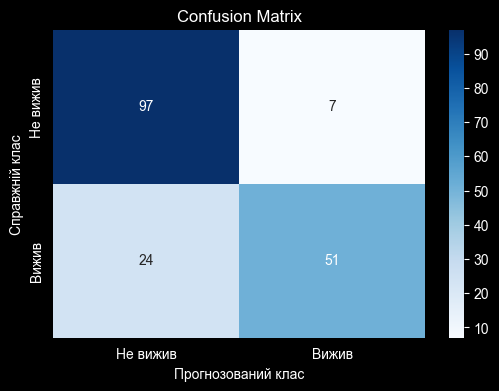

In [165]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Не вижив", "Вижив"],
    yticklabels=["Не вижив", "Вижив"]
)

plt.xlabel("Прогнозований клас")
plt.ylabel("Справжній клас")
plt.title("Confusion Matrix")
plt.show()

In [166]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.93      0.86       104
           1       0.88      0.68      0.77        75

    accuracy                           0.83       179
   macro avg       0.84      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



Для класу 0:

precision = 0.8 — 80% пасажирів, яких модель віднесла до класу не вижив, дійсно не вижили;
recall = 0.93 — модель змогла правильно знайти 93% усіх пасажирів, які не вижили;
f1-score = 0.86 — узагальнена оцінка якості класифікації для цього класу.

Для класу 1:

precision = 0.88 — 88% прогнозів виживання були правильними;
recall = 0.68 — модель виявила 68% усіх пасажирів, які вижили;
f1-score = 0.77.

Загальна точність моделі становить 0.83, тобто модель правильно класифікує приблизно 83% об’єктів тестової вибірки.
macro avg - середнє значення метрик без урахування кількості об’єктів у класах.
weighted avg - середнє значення метрик з урахуванням кількості об’єктів у кожному класі.

Показники для класу 0 є вищими, ніж для класу 1, що свідчить про те, що модель краще визначає пасажирів, які не вижили. Це може бути пов’язано з певним дисбалансом класів у наборі даних. Загалом модель демонструє достатньо хорошу якість класифікації для базового дерева рішень.

In [167]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [168]:
df["Survived"].value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

Аналіз балансу класів показав, що клас 0 переважає над класом 1: не вижило 549 пасажирів, що становить приблизно 61.6% вибірки, а вижило 342 пасажири, тобто приблизно 38.4%. Отже, класи є помірно незбалансованими, тому для оцінювання моделі важливо враховувати не лише accuracy, а й precision, recall та F1-score.

Для цього завдання більш інформативними є precision, recall та F1-score, а не лише accuracy.

Accuracy показує загальну частку правильних відповідей, але не пояснює, як саме модель працює з кожним класом окремо. У нас класи є нерівномірними: пасажирів, які не вижили, більше, ніж тих, хто вижив. Тому модель може частіше правильно визначати клас 0 і через це мати нормальну accuracy, але гірше знаходити клас 1.

Найбільш корисними метриками тут є:

Recall для класу 1, бо він показує, яку частину пасажирів, які справді вижили, модель змогла правильно знайти.

Precision для класу 1, бо він показує, наскільки правильними були прогнози моделі про виживання.

F1-score, бо він поєднує precision і recall в одну метрику та краще підходить, коли класи не повністю збалансовані.

In [169]:
feature_importance = pd.DataFrame({
    "Ознака": X.columns,
    "Важливість": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Важливість",
    ascending=False
)

feature_importance

,Ознака,Важливість
1,Sex,0.397960
2,Age,0.189039
5,Fare,0.181042
0,Pclass,0.142431
3,SibSp,0.045369
4,Parch,0.032728
6,Embarked,0.011430


Аналіз важливості ознак показав, що найбільший вплив на виживання пасажирів мала ознака Sex. Це означає, що стать була найважливішим фактором під час класифікації. Також значний вплив мають Age та Fare, тобто вік пасажира і вартість квитка. Отже, модель найбільше враховує соціальну складову пасажирів.

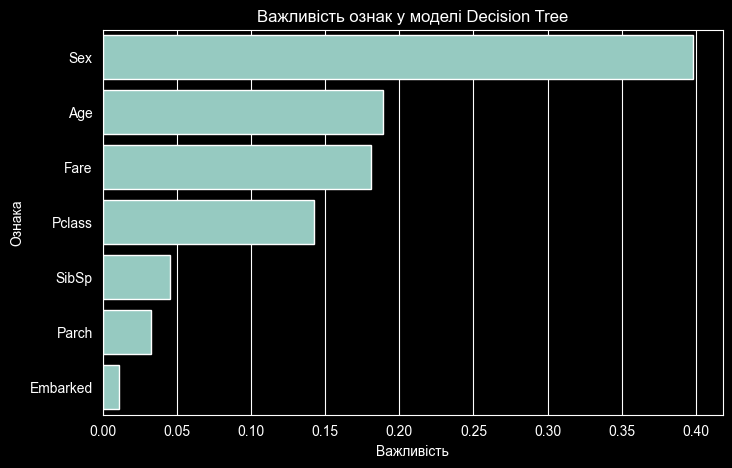

In [170]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Важливість",
    y="Ознака"
)

plt.title("Важливість ознак у моделі Decision Tree")
plt.xlabel("Важливість")
plt.ylabel("Ознака")

plt.show()

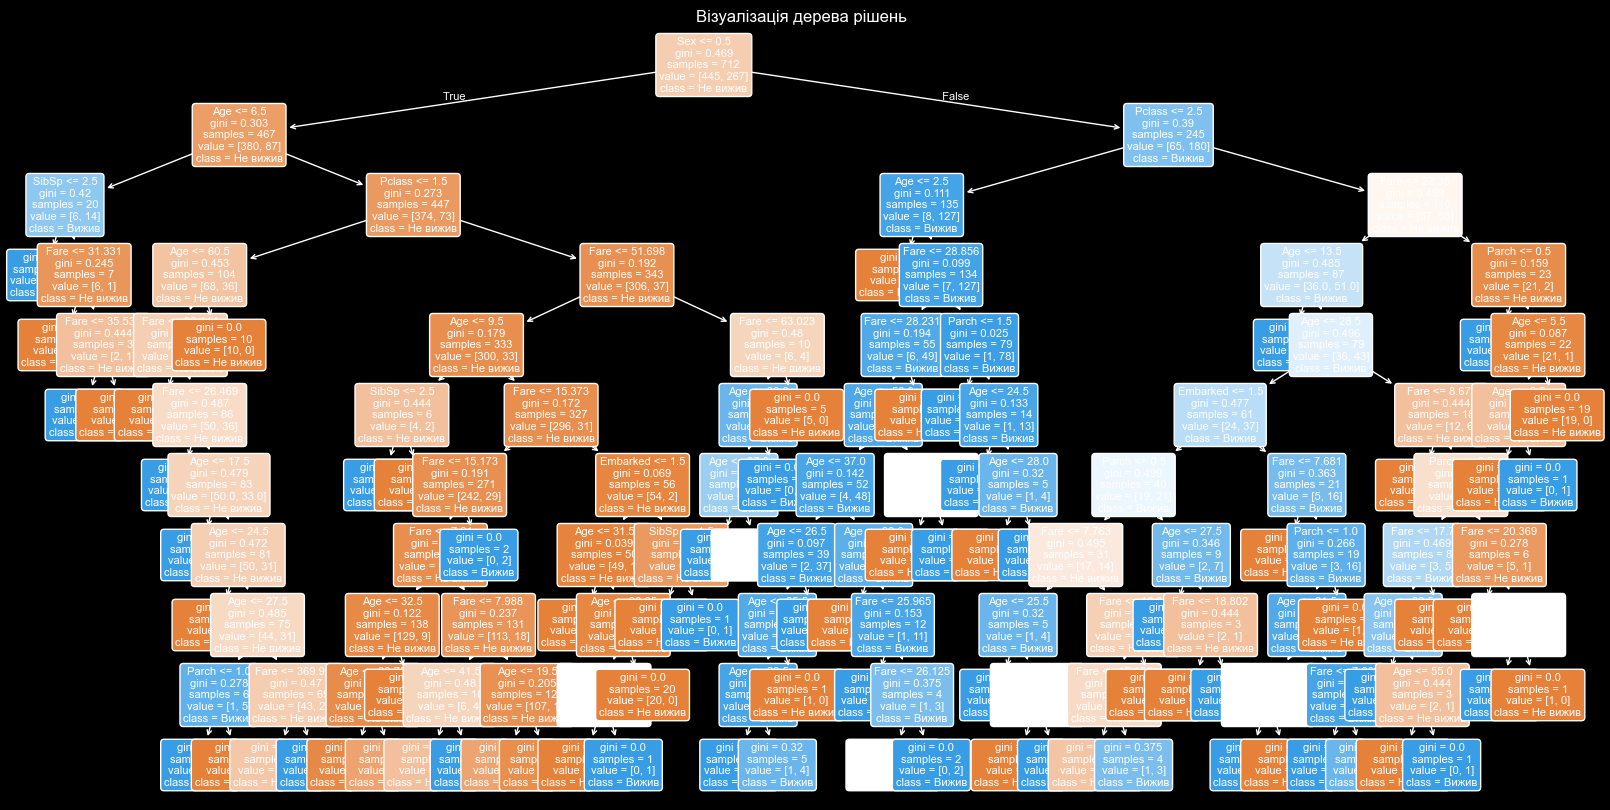

In [171]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Не вижив", "Вижив"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Візуалізація дерева рішень")
plt.show()

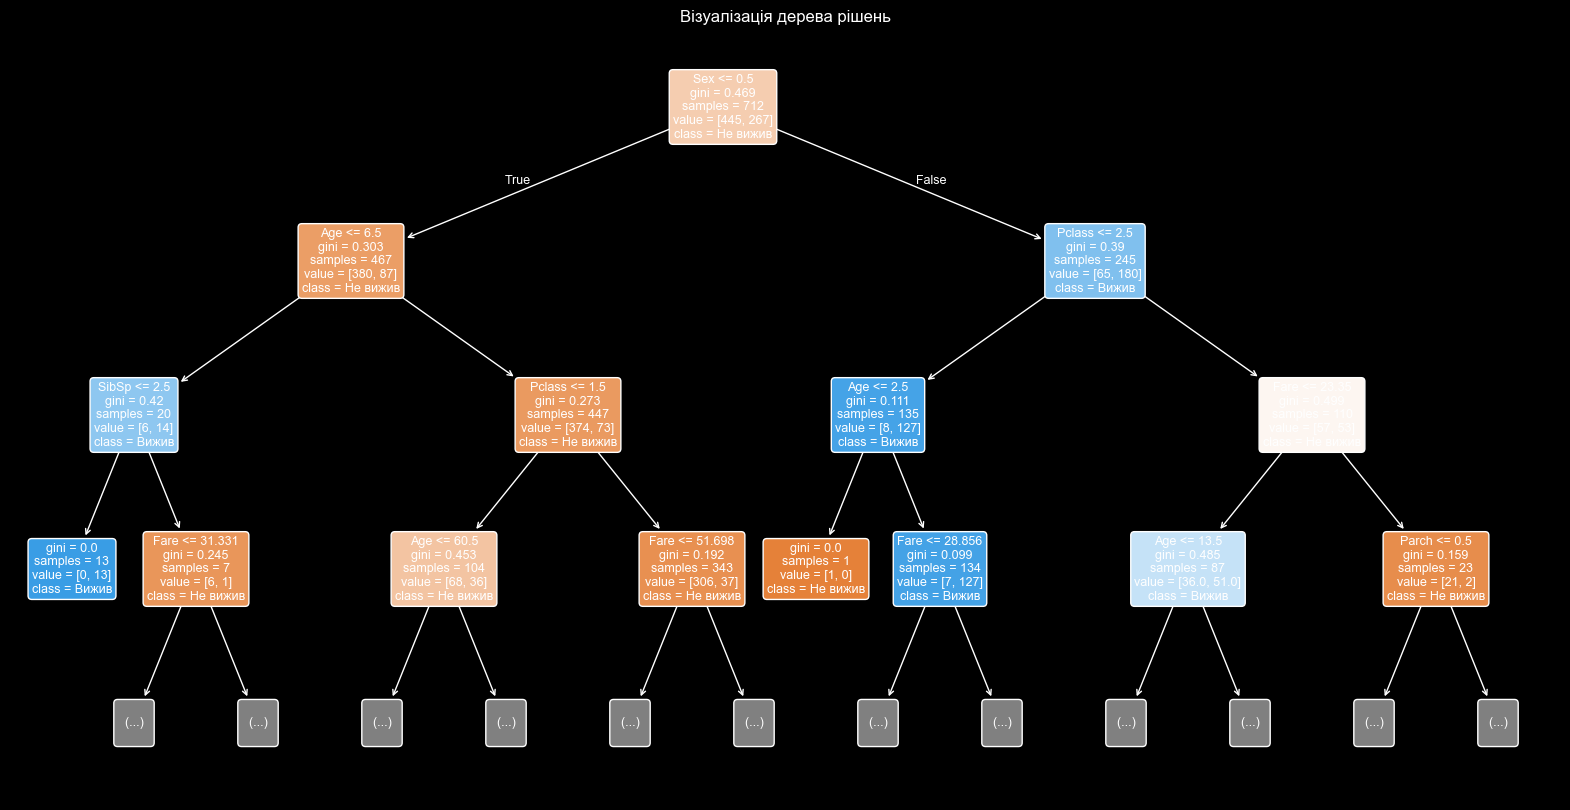

In [172]:
plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Не вижив", "Вижив"],
    filled=True,
    rounded=True,
    fontsize=9,
    max_depth=3
)

plt.title("Візуалізація дерева рішень")
plt.show()

Кореневим вузлом є ознака Sex, тобто саме стать є найважливішою характеристикою для прогнозування виживання пасажирів. Далі модель використовує ознаки Pclass, Age, Fare, SibSp та Parch. Сині вузли відповідають класу 1, а помаранчеві — класу 0. Чим насиченіший колір, тим впевненіше модель класифікує об’єкти у відповідний клас. Видно, що жінки та пасажири вищих класів мали більшу ймовірність виживання, тоді як чоловіки та пасажири нижчих класів частіше потрапляли до класу 0. Повне дерево є досить великим і складним, що свідчить про детальний поділ даних та можливе часткове перенавчання моделі.

In [173]:
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("Train accuracy:", train_accuracy)
print("Test accuracy:", test_accuracy)
print("Різниця:", train_accuracy - test_accuracy)

Train accuracy: 0.9129213483146067
Test accuracy: 0.8268156424581006
Різниця: 0.08610570585650612


Отримані результати свідчать про відсутність перенавчання (overfitting) моделі.

In [174]:
from sklearn.tree import DecisionTreeClassifier
import pandas as pd

results = []

for depth in range(1, 16):
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=100
    )

    model.fit(X_train, y_train)

    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)

    results.append({
        "max_depth": depth,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "difference": train_accuracy - test_accuracy
    })

depth_results = pd.DataFrame(results)

depth_results

,max_depth,train_accuracy,test_accuracy,difference
0,1,0.786517,0.787709,-0.001193
1,2,0.803371,0.765363,0.038008
2,3,0.832865,0.804469,0.028396
3,4,0.834270,0.804469,0.029800
4,5,0.849719,0.798883,0.050836
5,6,0.858146,0.804469,0.053677
6,7,0.876404,0.804469,0.071935
7,8,0.887640,0.821229,0.066411
8,9,0.898876,0.810056,0.088821
9,10,0.912921,0.826816,0.086106


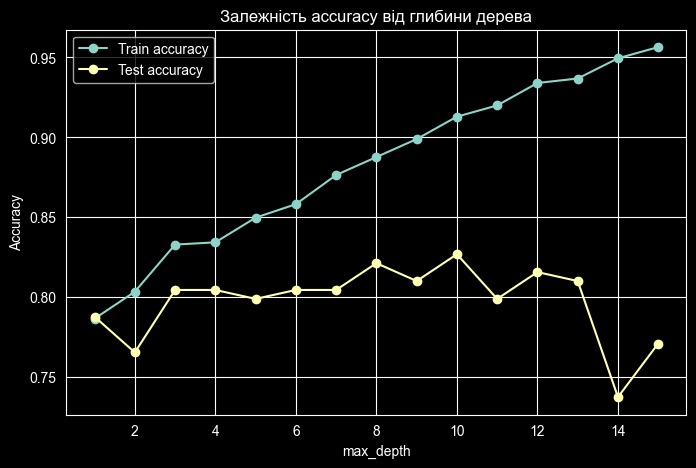

In [175]:
plt.figure(figsize=(8, 5))

plt.plot(depth_results["max_depth"], depth_results["train_accuracy"], marker="o", label="Train accuracy")
plt.plot(depth_results["max_depth"], depth_results["test_accuracy"], marker="o", label="Test accuracy")

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Залежність accuracy від глибини дерева")
plt.legend()
plt.grid(True)

plt.show()

In [176]:
best_depth = depth_results.loc[
    depth_results["test_accuracy"].idxmax()
]

best_depth

max_depth         10.000000
train_accuracy     0.912921
test_accuracy      0.826816
difference         0.086106
Name: 9, dtype: float64

У ході лабораторної роботи було досліджено задачу класифікації на прикладі набору даних Titanic. Було побудовано модель класифікації на основі дерева рішень та проведено оцінювання її якості за допомогою метрик accuracy, precision, recall і F1-score. Аналіз результатів показав, що модель демонструє достатньо хорошу якість класифікації. Також було виконано аналіз важливості ознак і встановлено, що найбільший вплив на виживання пасажирів мають стать, вік та клас каюти. Додатково було досліджено вплив глибини дерева на якість моделі та виявлено ознаки перенавчання. Підбір параметра max_depth дозволив покращити узагальнюючу здатність моделі та отримати більш стабільні результати класифікації.